# Set Up

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
TRIAL_1_DATA_PATH = "../Data/CleanData/Trial_1_Mean_Sensor_FW_No_Lag.csv"
TRIAL_2_DATA_PATH = "../Data/CleanData/Trial_2_Mean_Sensor_FW_No_Lag.csv"

def load_trial_1_data(path = TRIAL_1_DATA_PATH):
    df = pd.read_csv(path)
    # add change in fresh weigh variable
    df['fw_change_g'] = df.groupby('plant-id')['total_fresh_weight_g'].diff().fillna(0)
    # drop vairables not in trial 2 and plant-id
    df.drop(columns=['baseline_g', 'volume_flow_rate', 'volume', 'total_fresh_weight_g', 'plant-id'], inplace=True)
    return df

def load_trial_2_data(path = TRIAL_2_DATA_PATH):
    df = pd.read_csv(path)
    df.drop(columns=['plant_id', 'total_fresh_weight_g'], inplace=True)
    return df

def load_combined_data():
    df_1 = load_trial_1_data()
    df_2 = load_trial_2_data()
    combined_df = pd.concat([df_1, df_2], ignore_index=True)
    combined_df.sort_values(by=['day', 'fw_change_g'], inplace=True)
    combined_df = combined_df [ (combined_df['day'] > 0) ].reset_index(drop=True)
    return combined_df

# template for change in fresh weigth variable
# df_mean_sensor_and_lettuce_fw_4days['fw_change_g'] = df_mean_sensor_and_lettuce_fw_4days.groupby('plant_id')['total_fresh_weight_g'].diff().fillna(0) 

In [25]:
df = load_combined_data()
df

,day,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
0,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,4.0
1,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.2
2,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.7
3,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,7.3
4,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,8.3
...,...,...,...,...,...,...,...,...
135,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,77.0
136,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,78.0
137,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,79.0
138,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,80.0


In [ ]:
# summary of average 4 day water temperature values across all plants
df['temp_nutr'].describe()

count    140.000000
mean      23.923137
std        1.575199
min       21.611981
25%       22.273844
50%       23.772489
75%       25.308837
max       26.928286
Name: temp_nutr, dtype: float64

In [ ]:
# summary of average 4 day electrical conductivity values across all plants
df['electrical_conductivity'].describe()

count     140.000000
mean     1580.194331
std       205.272353
min      1361.010204
25%      1453.158710
50%      1494.233231
75%      1668.877551
max      2112.959184
Name: electrical_conductivity, dtype: float64

In [ ]:
# summary of average 4 day humidity values across all plants
df['humidity'].describe()

count    140.000000
mean      66.818731
std        7.627450
min       52.372857
25%       62.214082
50%       68.792179
75%       72.385926
max       77.851267
Name: humidity, dtype: float64

array([[<Axes: title={'center': 'day'}>,
        <Axes: title={'center': 'carbon_dioxide'}>,
        <Axes: title={'center': 'temp_env'}>],
       [<Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'pressure'}>,
        <Axes: title={'center': 'electrical_conductivity'}>],
       [<Axes: title={'center': 'temp_nutr'}>,
        <Axes: title={'center': 'fw_change_g'}>, <Axes: >]], dtype=object)

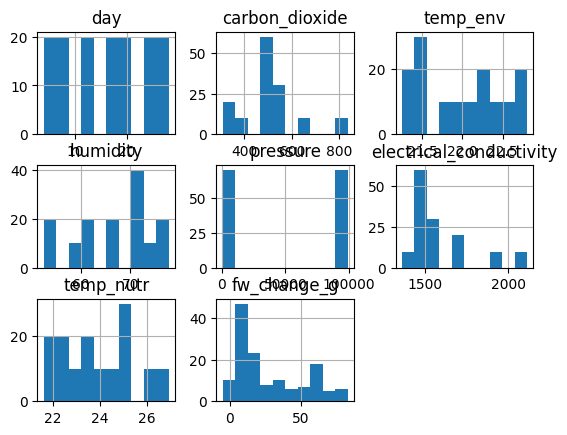

In [30]:
df.hist()

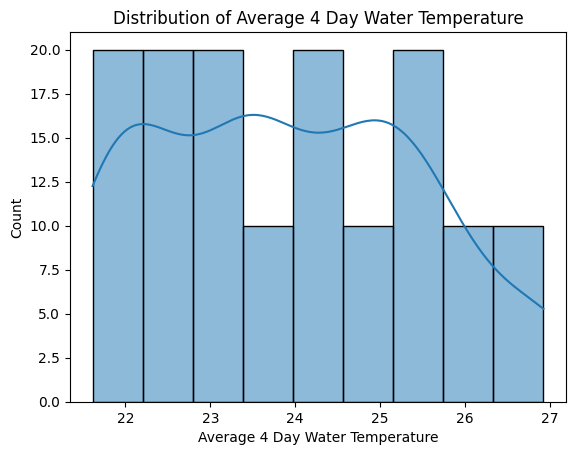

In [ ]:
# distribution of average 4 day temperature values
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df, x='temp_nutr', kde=True)
plt.title('Distribution of Average 4 Day Water Temperature')
plt.xlabel('Average 4 Day Water Temperature')
plt.savefig('../Figures/eda/kde_temp_nutr.png')
plt.show()

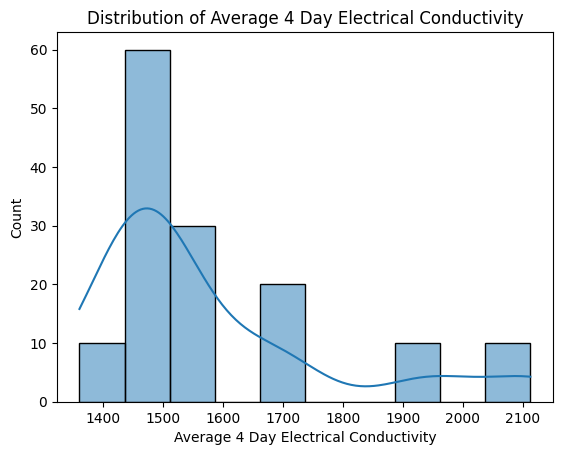

In [ ]:
# distribution of average 4 day electrical conductivity values
sns.histplot(df, x='electrical_conductivity', kde=True)
plt.title('Distribution of Average 4 Day Electrical Conductivity')
plt.xlabel('Average 4 Day Electrical Conductivity')
plt.savefig('../Figures/eda/kde_electrical_conductivity.png')   
plt.show()

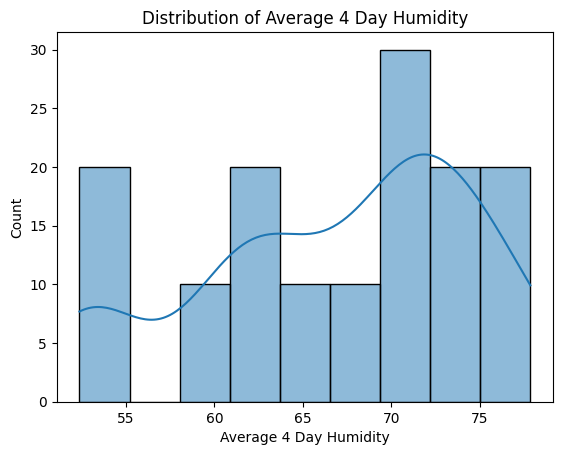

In [39]:
# distribution of average 4 day humidity values
sns.histplot(df, x='humidity', kde=True)
plt.title('Distribution of Average 4 Day Humidity')
plt.xlabel('Average 4 Day Humidity')
plt.savefig('../Figures/eda/kde_humidity.png')
plt.show()

# Neural Network 1

Fold [1/5], Final Val Loss (MSE): 46.8886, Final Val RMSE: 6.8475


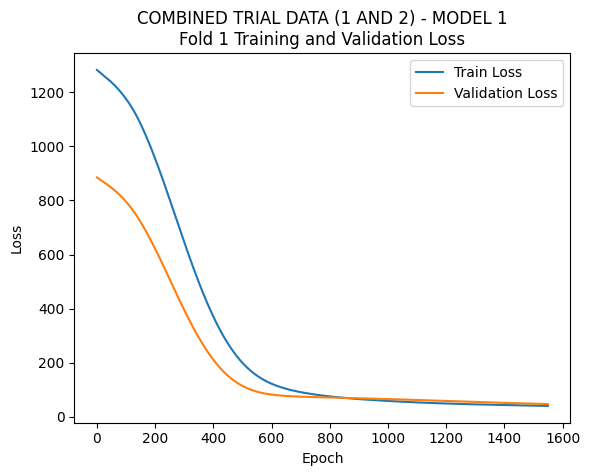

Fold [2/5], Final Val Loss (MSE): 49.2070, Final Val RMSE: 7.0148


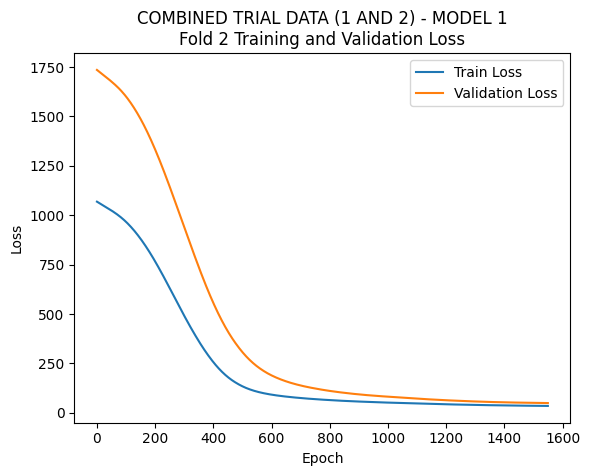

Fold [3/5], Final Val Loss (MSE): 61.6444, Final Val RMSE: 7.8514


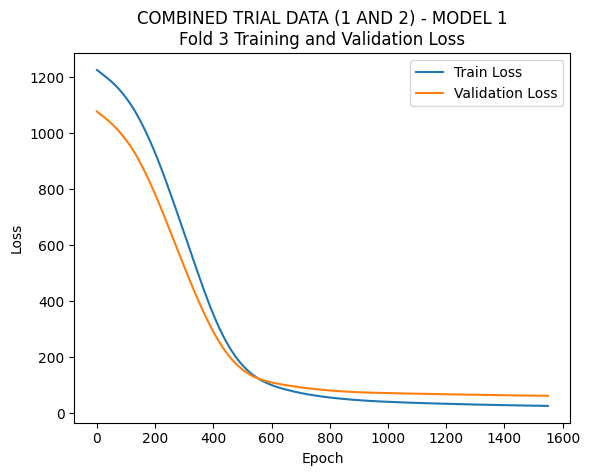

Fold [4/5], Final Val Loss (MSE): 24.0784, Final Val RMSE: 4.9070


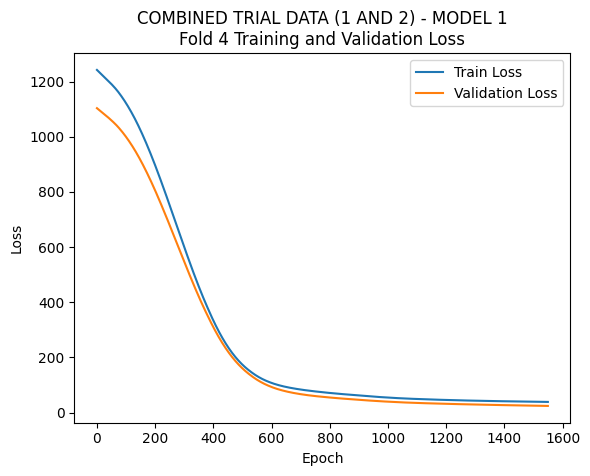

Fold [5/5], Final Val Loss (MSE): 41.9812, Final Val RMSE: 6.4793


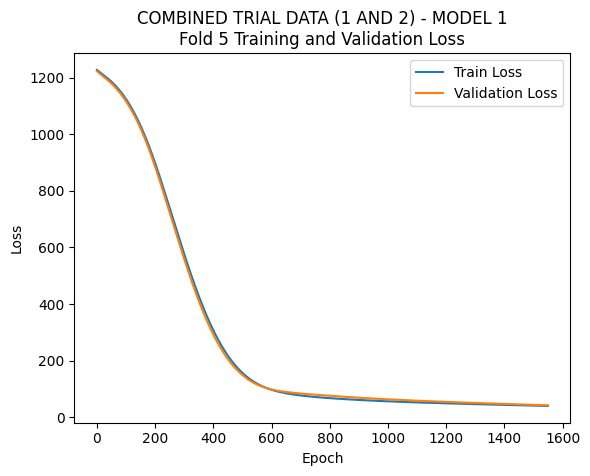


Mean CV Val Loss (MSE): 44.7599
Mean CV Val Loss (RMSE): 6.6903
Std CV Val Loss (MSE): 12.2052
Std CV Val Loss (RMSE): 3.4936


In [3]:

# load data 

import torch
import numpy as np


df = load_combined_data()

target_col = 'fw_change_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1550

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"COMBINED TRIAL DATA (1 AND 2) - MODEL 1\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_1_fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nMean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")


Epoch [1/1550], Train Loss: 1202.1559
Epoch [2/1550], Train Loss: 1201.2794
Epoch [3/1550], Train Loss: 1200.4047
Epoch [4/1550], Train Loss: 1199.5322
Epoch [5/1550], Train Loss: 1198.6591
Epoch [6/1550], Train Loss: 1197.7867
Epoch [7/1550], Train Loss: 1196.9158
Epoch [8/1550], Train Loss: 1196.0461
Epoch [9/1550], Train Loss: 1195.1832
Epoch [10/1550], Train Loss: 1194.3309
Epoch [11/1550], Train Loss: 1193.4783
Epoch [12/1550], Train Loss: 1192.6289
Epoch [13/1550], Train Loss: 1191.7793
Epoch [14/1550], Train Loss: 1190.9285
Epoch [15/1550], Train Loss: 1190.0765
Epoch [16/1550], Train Loss: 1189.2253
Epoch [17/1550], Train Loss: 1188.3737
Epoch [18/1550], Train Loss: 1187.5248
Epoch [19/1550], Train Loss: 1186.6748
Epoch [20/1550], Train Loss: 1185.8217
Epoch [21/1550], Train Loss: 1184.9670
Epoch [22/1550], Train Loss: 1184.1106
Epoch [23/1550], Train Loss: 1183.2526
Epoch [24/1550], Train Loss: 1182.3929
Epoch [25/1550], Train Loss: 1181.5323
Epoch [26/1550], Train Loss: 1180.

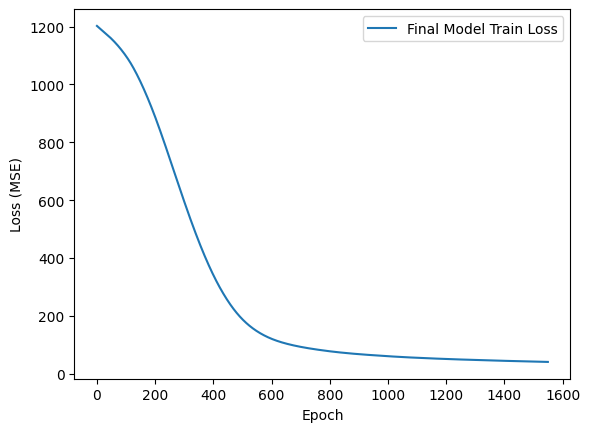

In [4]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1550

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model1 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model1.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model1.train()
    outputs = model1(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model1.eval()
with torch.no_grad():
    test_outputs = model1(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_1_final_training_loss.png')
plt.show()

## Permutation Importance


Baseline RMSE: 6.158334

Permutation results (20-repeat average):
day                        RMSE=19.5362  (Δ=+13.3779,  sd=1.7133)
electrical_conductivity    RMSE=15.9662  (Δ=+9.8078,  sd=1.7317)
temp_nutr                  RMSE=9.7784  (Δ=+3.6200,  sd=0.8890)
humidity                   RMSE=9.6936  (Δ=+3.5352,  sd=0.8459)
temp_env                   RMSE=8.7748  (Δ=+2.6165,  sd=0.9847)
pressure                   RMSE=8.6095  (Δ=+2.4511,  sd=0.8320)
carbon_dioxide             RMSE=6.5061  (Δ=+0.3478,  sd=0.3207)


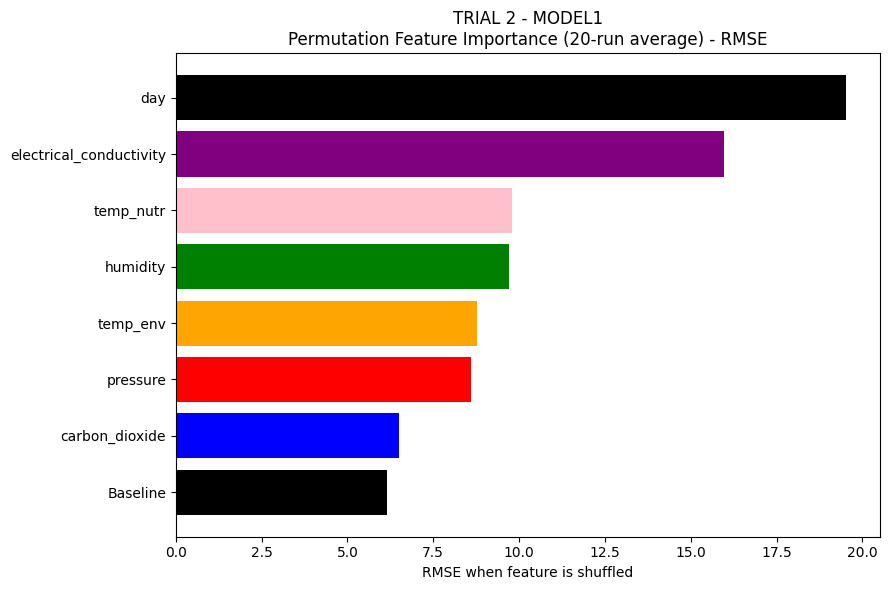

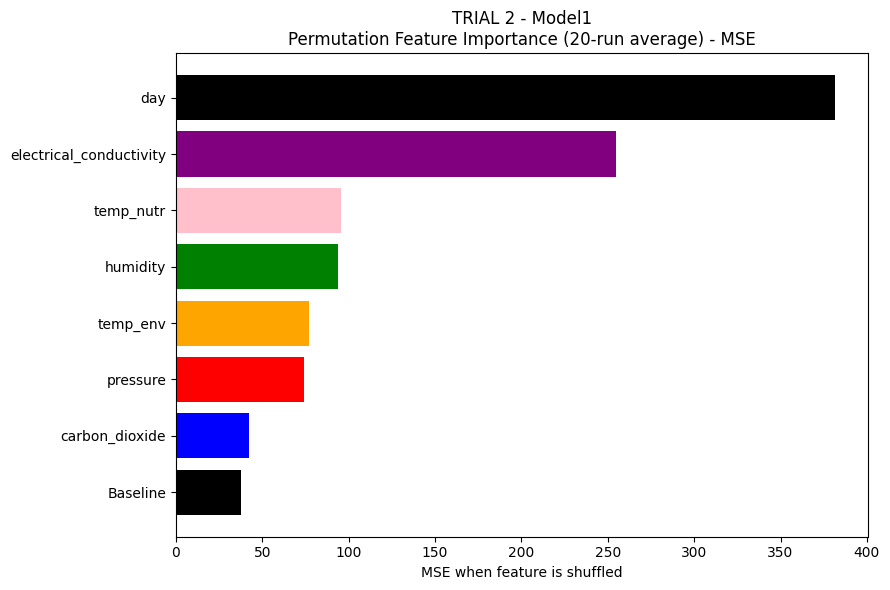

In [5]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model1.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model1(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model1(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("TRIAL 2 - MODEL1\nPermutation Feature Importance (20-run average) - RMSE")
plt.tight_layout()

plt.savefig('../Figures/t2_nn_model1_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("TRIAL 2 - Model1\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/nnmodel1_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

# Neural Network 2
Dropping Day Feature

## Model Training

Fold [1/5], Final Val Loss (MSE): 28.7147, Final Val RMSE: 5.3586


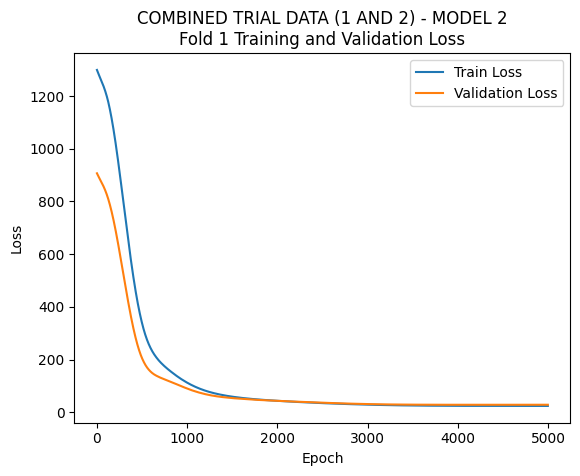

Fold [2/5], Final Val Loss (MSE): 30.1629, Final Val RMSE: 5.4921


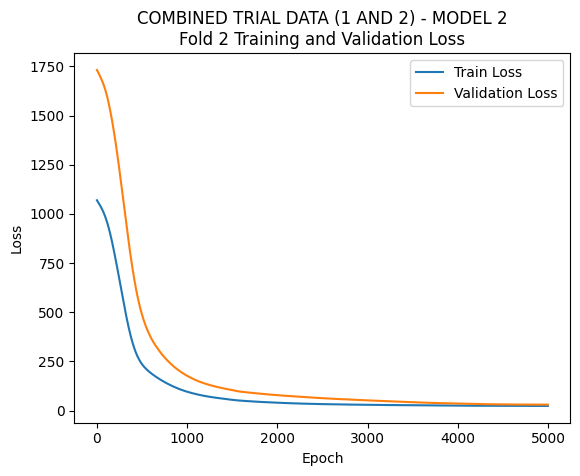

Fold [3/5], Final Val Loss (MSE): 53.6867, Final Val RMSE: 7.3271


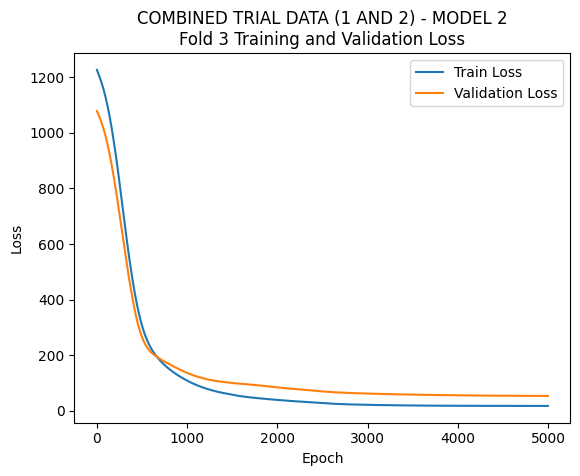

Fold [4/5], Final Val Loss (MSE): 9.8186, Final Val RMSE: 3.1335


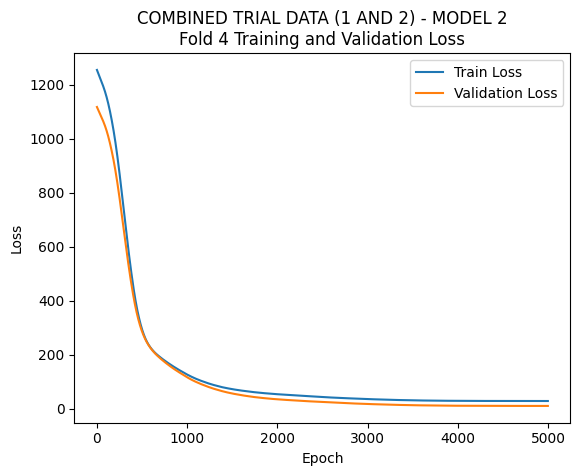

Fold [5/5], Final Val Loss (MSE): 21.6950, Final Val RMSE: 4.6578


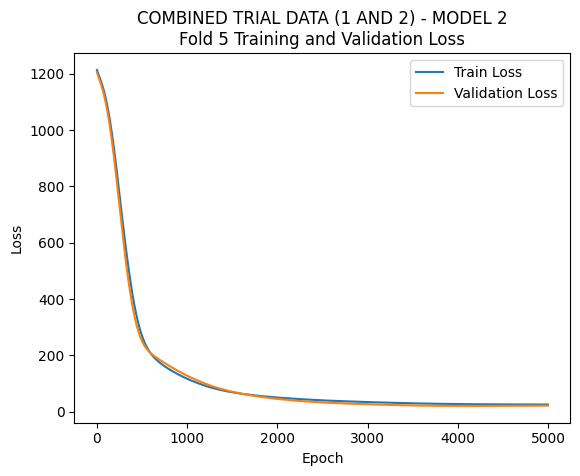


Mean CV Val Loss (MSE): 28.8156
Mean CV Val Loss (RMSE): 5.3680
Std CV Val Loss (MSE): 14.3665
Std CV Val Loss (RMSE): 3.7903


In [6]:

# load data 

import torch
import numpy as np


df = load_combined_data()
df = df.drop(columns=['day']) # drop day feature for model 2

target_col = 'fw_change_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32)

feature_names = df.drop(columns=[target_col]).columns.tolist()

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    
# pick manual seed
torch.manual_seed(42)

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 5000

# loss function
criterion = nn.MSELoss()

# cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_train_fold = X_train[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # standardize within each fold
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)
    
    # convert to tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32).view(-1, 1)
    
    # initialize model
    model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    train_losses = []
    val_losses = []
    
    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor) # get predicted results
        loss = criterion(outputs, y_train_tensor) 
        optimizer.zero_grad() 
        loss.backward() # compute gradients
        optimizer.step() # update weights
        
        train_losses.append(loss.item())
        
        # validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor)
        
        val_losses.append(val_loss.item())
    
    cv_val_losses.append(val_losses[-1])
    
    print(f"Fold [{fold+1}/5], Final Val Loss (MSE): {val_losses[-1]:.4f}, Final Val RMSE: {np.sqrt(val_losses[-1]):.4f}")
    
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"COMBINED TRIAL DATA (1 AND 2) - MODEL 2\nFold {fold+1} Training and Validation Loss")
    plt.legend()
    plt.savefig(f'../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_2_fold_{fold+1}_training_validation_loss.png')
    plt.show()

print(f"\nMean CV Val Loss (MSE): {np.mean(cv_val_losses):.4f}")
print(f"Mean CV Val Loss (RMSE): {np.sqrt(np.mean(cv_val_losses)):.4f}")
print(f"Std CV Val Loss (MSE): {np.std(cv_val_losses):.4f}")
print(f"Std CV Val Loss (RMSE): {np.sqrt(np.std(cv_val_losses)):.4f}")


Epoch [1/1550], Train Loss: 1218.2428
Epoch [2/1550], Train Loss: 1217.3561
Epoch [3/1550], Train Loss: 1216.4724
Epoch [4/1550], Train Loss: 1215.5918
Epoch [5/1550], Train Loss: 1214.7142
Epoch [6/1550], Train Loss: 1213.8397
Epoch [7/1550], Train Loss: 1212.9749
Epoch [8/1550], Train Loss: 1212.1152
Epoch [9/1550], Train Loss: 1211.2631
Epoch [10/1550], Train Loss: 1210.4143
Epoch [11/1550], Train Loss: 1209.5676
Epoch [12/1550], Train Loss: 1208.7230
Epoch [13/1550], Train Loss: 1207.8820
Epoch [14/1550], Train Loss: 1207.0488
Epoch [15/1550], Train Loss: 1206.2181
Epoch [16/1550], Train Loss: 1205.3907
Epoch [17/1550], Train Loss: 1204.5660
Epoch [18/1550], Train Loss: 1203.7434
Epoch [19/1550], Train Loss: 1202.9236
Epoch [20/1550], Train Loss: 1202.1107
Epoch [21/1550], Train Loss: 1201.3036
Epoch [22/1550], Train Loss: 1200.5020
Epoch [23/1550], Train Loss: 1199.7031
Epoch [24/1550], Train Loss: 1198.9071
Epoch [25/1550], Train Loss: 1198.1144
Epoch [26/1550], Train Loss: 1197.

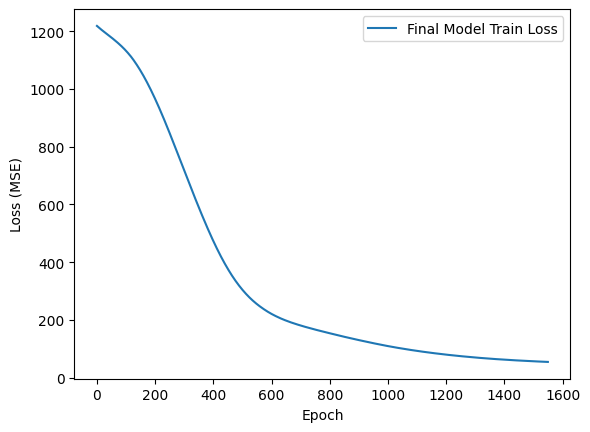

In [7]:
# train final model on full training set

# hyperparameters    
input_size = X_train.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1550

# standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# initialize model
torch.manual_seed(42)
model2 = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(model2.parameters(), lr=learning_rate)

# train final model and store training loss
train_losses = []

for epoch in range(num_epochs):
    model2.train()
    outputs = model2(X_train_tensor) # get predicted results
    loss = criterion(outputs, y_train_tensor) 
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

# final test evaluation
model2.eval()
with torch.no_grad():
    test_outputs = model2(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

print(f"\nFinal Test Loss (MSE): {test_loss.item():.4f}")
print(f"Final Test Loss (RMSE): {np.sqrt(test_loss.item()):.4f}")

plt.plot(train_losses, label="Final Model Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.savefig('../Figures/COMBINED_TRIAL_1_2_DATA_MODEL_2_final_training_loss.png')
plt.show()

## Permuation Importance

Baseline RMSE: 7.572384

Permutation results (20-repeat average):
electrical_conductivity    RMSE=32.3405  (Δ=+24.7681,  sd=3.4409)
temp_nutr                  RMSE=17.4763  (Δ=+9.9039,  sd=2.2172)
humidity                   RMSE=15.3412  (Δ=+7.7688,  sd=1.1689)
temp_env                   RMSE=10.8336  (Δ=+3.2612,  sd=1.0453)
pressure                   RMSE=10.5640  (Δ=+2.9916,  sd=1.6810)
carbon_dioxide             RMSE=7.8046  (Δ=+0.2322,  sd=0.1485)


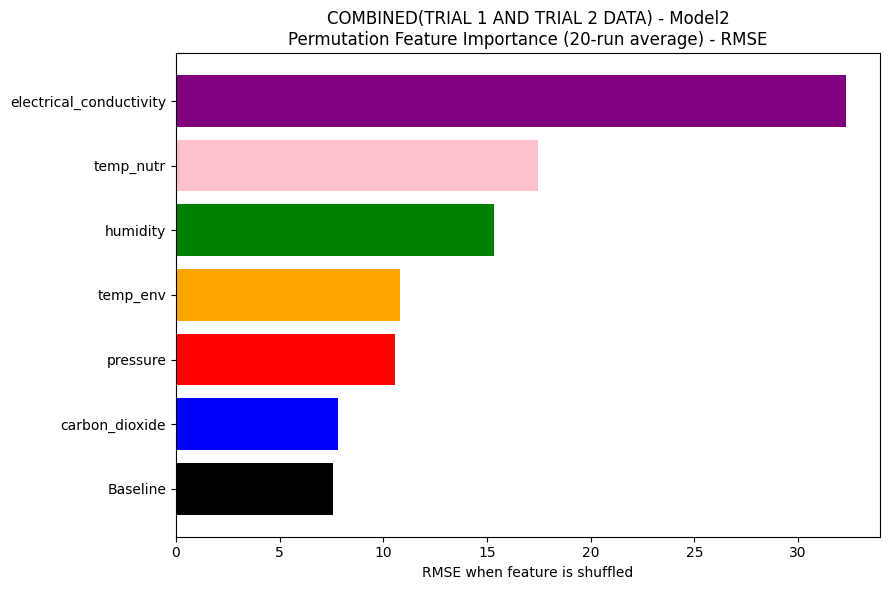

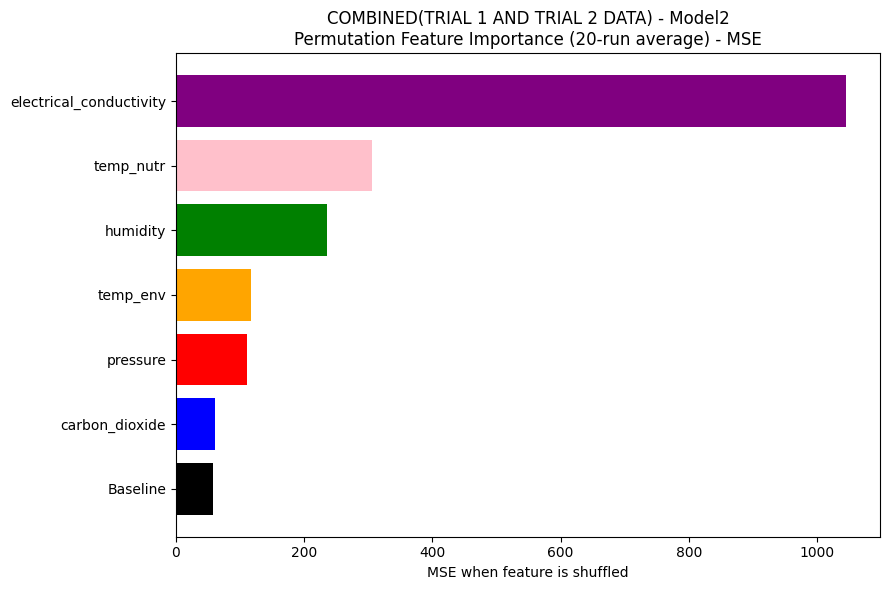

In [8]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model2.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model2(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model2(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("COMBINED(TRIAL 1 AND TRIAL 2 DATA) - Model2\nPermutation Feature Importance (20-run average) - RMSE")
plt.tight_layout()

plt.savefig('../Figures/combined_nnmodel2_permutation_importance_rmse.png', bbox_inches='tight')
plt.show()

# plot for mse instead of rmse
plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], [r**2 for r in rmses_plot][::-1], color=colors_plot[::-1])
plt.xlabel("MSE when feature is shuffled")
plt.title("COMBINED(TRIAL 1 AND TRIAL 2 DATA) - Model2\nPermutation Feature Importance (20-run average) - MSE")
plt.tight_layout()
plt.savefig('../Figures/combined_nnmodel2_permutation_importance_mse.png', bbox_inches='tight')
plt.show()

Combinations of features Permutation Importance
features to permute : {electrical_conductivity, temp_nutr, humidity}

### Combination Permutation Importance

Baseline RMSE: 7.572384

Permutation results (20-repeat average):
electrical_conductivity + humidity                 RMSE=35.8186 (Δ=+28.2462, sd=3.2250)
electrical_conductivity + temp_nutr + humidity     RMSE=34.9323 (Δ=+27.3599, sd=3.3927)
electrical_conductivity                            RMSE=33.2959 (Δ=+25.7235, sd=2.7227)
electrical_conductivity + temp_nutr                RMSE=32.5746 (Δ=+25.0023, sd=4.0906)
temp_nutr + humidity                               RMSE=23.5249 (Δ=+15.9526, sd=1.8699)
temp_nutr                                          RMSE=17.1504 (Δ=+9.5780, sd=2.4154)
humidity                                           RMSE=15.3412 (Δ=+7.7688, sd=1.1689)


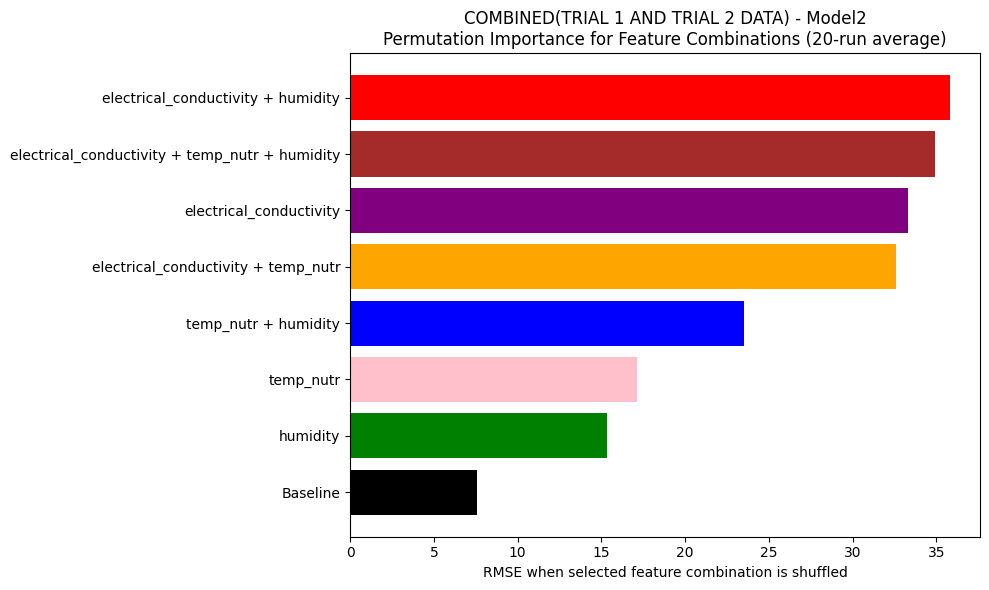

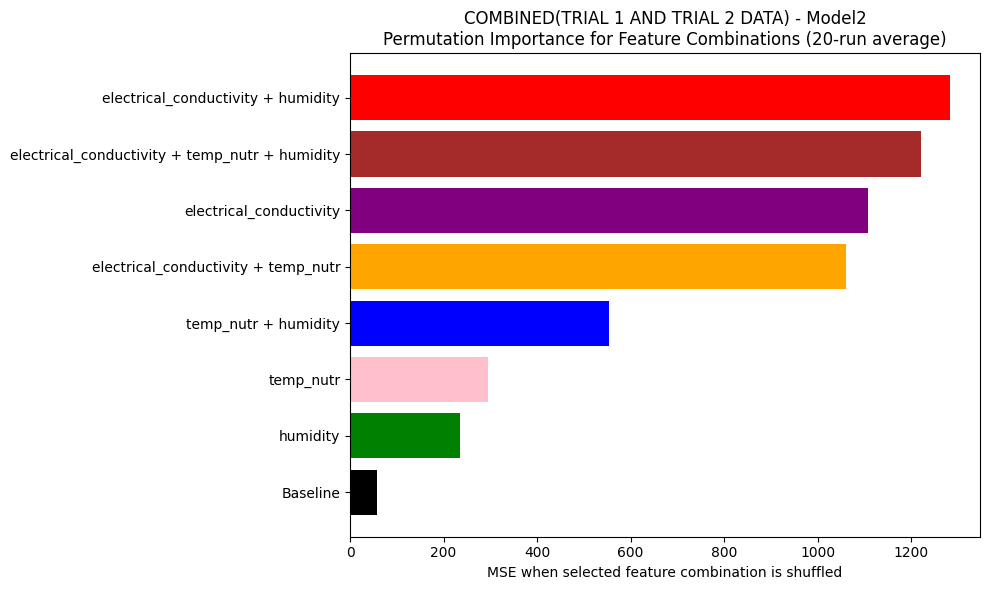

In [9]:
import numpy as np
import torch
import itertools
import matplotlib.pyplot as plt

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model2.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model2(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Choose features to permute
# ==============================
target_features = ['electrical_conductivity', 'temp_nutr', 'humidity']
target_indices = [feature_names.index(f) for f in target_features]

# Build all non-empty combinations
feature_combos = []
for k in range(1, len(target_features) + 1):
    feature_combos.extend(itertools.combinations(range(len(target_features)), k))

# ==============================
# Permutation Importance for combinations (20 repeats)
# ==============================
repeats = 20
perm_results = []
torch.manual_seed(42)

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for combo in feature_combos:
    rmses = []

    combo_feature_names = [target_features[i] for i in combo]
    combo_feature_indices = [target_indices[i] for i in combo]
    combo_label = " + ".join(combo_feature_names)

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # Permute each feature in the combo independently
        for j in combo_feature_indices:
            idx = torch.randperm(N)
            X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model2(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)
    perm_results.append((combo_label, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:50s} RMSE={avg_rmse:.4f} (Δ={delta:+.4f}, sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================
combo_colors = {
    'electrical_conductivity': 'purple',
    'temp_nutr': 'pink',
    'humidity': 'green',
    'electrical_conductivity + temp_nutr': 'orange',
    'electrical_conductivity + humidity': 'red',
    'temp_nutr + humidity': 'blue',
    'electrical_conductivity + temp_nutr + humidity': 'brown'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [combo_colors.get(name, 'gray') for name in names]

# Add baseline bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(10, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when selected feature combination is shuffled")
plt.title("COMBINED(TRIAL 1 AND TRIAL 2 DATA) - Model2\nPermutation Importance for Feature Combinations (20-run average)")
plt.tight_layout()
plt.savefig('../Figures/combined_nnmodel2_permutation_importance_feature_combos_rmse.png', bbox_inches='tight')
plt.show()

# ==============================
# MSE version
# ==============================
plt.figure(figsize=(10, 6))
plt.barh(
    names_plot[::-1],
    [r**2 for r in rmses_plot][::-1],
    color=colors_plot[::-1]
)
plt.xlabel("MSE when selected feature combination is shuffled")
plt.title("COMBINED(TRIAL 1 AND TRIAL 2 DATA) - Model2\nPermutation Importance for Feature Combinations (20-run average)")
plt.tight_layout()
plt.savefig('../Figures/combined_nnmodel2_permutation_importance_feature_combos_mse.png', bbox_inches='tight')
plt.show()

In [10]:
df

,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,4.0
1,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.2
2,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.7
3,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,7.3
4,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,8.3
...,...,...,...,...,...,...,...
135,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,77.0
136,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,78.0
137,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,79.0
138,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,80.0


## perturbation analyis 

In [11]:
import numpy as np
import pandas as pd
import torch
import itertools

model2.eval()

# --------------------------------------------------
# Features to analyze
# --------------------------------------------------
selected_features = ["humidity", "electrical_conductivity", "temp_nutr"]

missing = [f for f in selected_features if f not in feature_names]
if missing:
    raise ValueError(f"These selected features are missing from feature_names: {missing}")

# --------------------------------------------------
# Helper: ensure predictions are 1D numpy
# --------------------------------------------------
def predict_numpy(model, X_tensor):
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor).detach().cpu().numpy()
    return preds.reshape(-1)

# --------------------------------------------------
# Single-feature perturbation
# --------------------------------------------------
def get_single_perturbed_predictions(model, X_tensor, feature_name, perturbation=0.1):
    X_perturbed = X_tensor.clone()
    j = feature_names.index(feature_name)
    X_perturbed[:, j] *= (1 + perturbation)

    baseline_preds = predict_numpy(model, X_tensor)
    perturbed_preds = predict_numpy(model, X_perturbed)

    return baseline_preds, perturbed_preds

# --------------------------------------------------
# Pair perturbation with separate directions
# --------------------------------------------------
def get_pair_perturbed_predictions(model, X_tensor, feature_a, feature_b, perturb_a=0.1, perturb_b=0.1):
    X_perturbed = X_tensor.clone()

    j_a = feature_names.index(feature_a)
    j_b = feature_names.index(feature_b)

    X_perturbed[:, j_a] *= (1 + perturb_a)
    X_perturbed[:, j_b] *= (1 + perturb_b)

    baseline_preds = predict_numpy(model, X_tensor)
    perturbed_preds = predict_numpy(model, X_perturbed)

    return baseline_preds, perturbed_preds

# --------------------------------------------------
# Baseline predictions
# --------------------------------------------------
baseline_preds = predict_numpy(model2, X_test_tensor)

# --------------------------------------------------
# Perturbation levels
# --------------------------------------------------
single_perturbation_levels = [-0.2, -0.1, 0.1, 0.2]
pair_perturbation_levels = [0.1, 0.2]

# --------------------------------------------------
# SINGLE-FEATURE RESULTS
# --------------------------------------------------
single_results = []

for feature in selected_features:
    row = {"feature": feature}

    for p in single_perturbation_levels:
        _, perturbed_preds = get_single_perturbed_predictions(
            model2, X_test_tensor, feature, perturbation=p
        )

        mean_effect = np.mean(perturbed_preds - baseline_preds)
        row[f"{int(p*100):+d}% effect (g)"] = mean_effect

    single_results.append(row)

single_perturbation_df = pd.DataFrame(single_results)

single_perturbation_df = single_perturbation_df.sort_values(
    by="+10% effect (g)",
    key=lambda x: x.abs(),
    ascending=False
).reset_index(drop=True)

single_perturbation_df = single_perturbation_df.round(4)

print("Single-feature perturbation results:")
print(single_perturbation_df)

# --------------------------------------------------
# PAIRWISE DIRECTIONAL RESULTS
# Column meanings:
# ++10% = both up 10%
# --10% = both down 10%
# +-10% = first feature up 10%, second down 10%
# -+10% = first feature down 10%, second up 10%
# --------------------------------------------------
pair_results = []
feature_pairs = list(itertools.combinations(selected_features, 2))

for feature_a, feature_b in feature_pairs:
    row = {"feature_pair": f"{feature_a} + {feature_b}"}

    for p in pair_perturbation_levels:
        scenarios = {
            f"++{int(p*100)}% effect (g)": (+p, +p),
            f"--{int(p*100)}% effect (g)": (-p, -p),
            f"+-{int(p*100)}% effect (g)": (+p, -p),
            f"-+{int(p*100)}% effect (g)": (-p, +p),
        }

        for col_name, (perturb_a, perturb_b) in scenarios.items():
            _, perturbed_preds = get_pair_perturbed_predictions(
                model2,
                X_test_tensor,
                feature_a,
                feature_b,
                perturb_a=perturb_a,
                perturb_b=perturb_b
            )

            mean_effect = np.mean(perturbed_preds - baseline_preds)
            row[col_name] = mean_effect

    pair_results.append(row)

pair_perturbation_directional_df = pd.DataFrame(pair_results)

scenario_cols = [col for col in pair_perturbation_directional_df.columns if col != "feature_pair"]

pair_perturbation_directional_df["_max_abs_effect"] = (
    pair_perturbation_directional_df[scenario_cols].abs().max(axis=1)
)

pair_perturbation_directional_df = pair_perturbation_directional_df.sort_values(
    by="_max_abs_effect",
    ascending=False
).drop(columns="_max_abs_effect").reset_index(drop=True)

pair_perturbation_directional_df = pair_perturbation_directional_df.round(4)

print("\nPairwise directional perturbation results:")
print(pair_perturbation_directional_df)

Single-feature perturbation results:
                   feature  -20% effect (g)  -10% effect (g)  +10% effect (g)  \
0  electrical_conductivity          -3.0852          -1.5428           1.4513   
1                 humidity          -0.7222          -0.3866           0.4259   
2                temp_nutr          -0.2474          -0.1387           0.0870   

   +20% effect (g)  
0           2.9274  
1           0.8508  
2           0.1963  

Pairwise directional perturbation results:
                          feature_pair  ++10% effect (g)  --10% effect (g)  \
0   humidity + electrical_conductivity            1.8616           -1.9472   
1  electrical_conductivity + temp_nutr            1.6652           -1.5654   
2                 humidity + temp_nutr            0.5118           -0.5299   

   +-10% effect (g)  -+10% effect (g)  ++20% effect (g)  --20% effect (g)  \
0           -1.1084            1.0893            3.7510           -3.8752   
1            1.3225           -1.4691      

In [12]:
single_perturbation_df

,feature,-20% effect (g),-10% effect (g),+10% effect (g),+20% effect (g)
0,electrical_conductivity,-3.0852,-1.5428,1.4513,2.9274
1,humidity,-0.7222,-0.3866,0.4259,0.8508
2,temp_nutr,-0.2474,-0.1387,0.0870,0.1963


In [13]:
pair_perturbation_directional_df

,feature_pair,++10% effect (g),--10% effect (g),+-10% effect (g),-+10% effect (g),++20% effect (g),--20% effect (g),+-20% effect (g),-+20% effect (g)
0,humidity + electrical_conductivity,1.8616,-1.9472,-1.1084,1.0893,3.7510,-3.8752,-2.2249,2.2979
1,electrical_conductivity + temp_nutr,1.6652,-1.5654,1.3225,-1.4691,3.3605,-3.1221,2.6771,-2.9571
2,humidity + temp_nutr,0.5118,-0.5299,0.2807,-0.2683,0.9865,-1.0124,0.5926,-0.4938


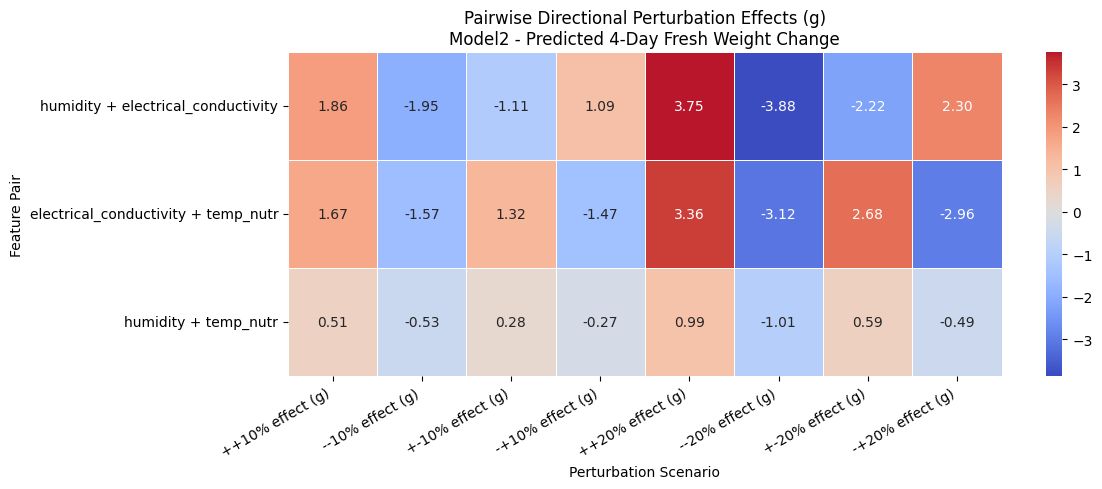

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set feature pair as index
df = pair_perturbation_directional_df.set_index("feature_pair")

# Keep only scenario columns
df = df.copy()

plt.figure(figsize=(12, 5))

sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pairwise Directional Perturbation Effects (g)\nModel2 - Predicted 4-Day Fresh Weight Change")
plt.ylabel("Feature Pair")
plt.xlabel("Perturbation Scenario")
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../Figures/combined_nnmodel2_pairwise_directional_heatmap.png', bbox_inches='tight')
plt.show()

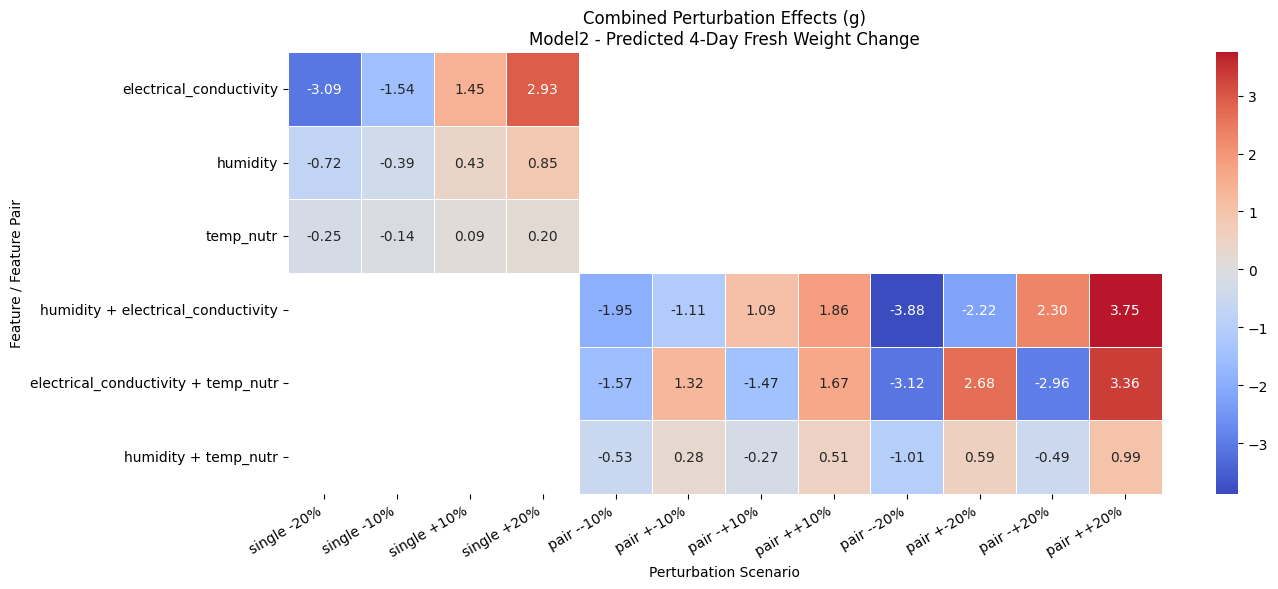

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs('../Figures', exist_ok=True)

# =========================================================
# 1) Format single-feature results for combined heatmap
# =========================================================
single_heatmap_df = single_perturbation_df.copy()
single_heatmap_df = single_heatmap_df.rename(columns={
    "feature": "row_name",
    "-20% effect (g)": "single -20%",
    "-10% effect (g)": "single -10%",
    "+10% effect (g)": "single +10%",
    "+20% effect (g)": "single +20%"
})

single_heatmap_df["row_type"] = "single"

# Keep only needed columns
single_heatmap_df = single_heatmap_df[[
    "row_name",
    "row_type",
    "single -20%",
    "single -10%",
    "single +10%",
    "single +20%"
]]

# =========================================================
# 2) Format pairwise directional results for combined heatmap
# =========================================================
pair_heatmap_df = pair_perturbation_directional_df.copy()
pair_heatmap_df = pair_heatmap_df.rename(columns={
    "feature_pair": "row_name",
    "++10% effect (g)": "pair ++10%",
    "--10% effect (g)": "pair --10%",
    "+-10% effect (g)": "pair +-10%",
    "-+10% effect (g)": "pair -+10%",
    "++20% effect (g)": "pair ++20%",
    "--20% effect (g)": "pair --20%",
    "+-20% effect (g)": "pair +-20%",
    "-+20% effect (g)": "pair -+20%"
})

pair_heatmap_df["row_type"] = "pair"

pair_heatmap_df = pair_heatmap_df[[
    "row_name",
    "row_type",
    "pair ++10%",
    "pair --10%",
    "pair +-10%",
    "pair -+10%",
    "pair ++20%",
    "pair --20%",
    "pair +-20%",
    "pair -+20%"
]]

# =========================================================
# 3) Combine into one dataframe
# =========================================================
combined_heatmap_df = pd.concat(
    [single_heatmap_df, pair_heatmap_df],
    axis=0,
    ignore_index=True
)

# Set row names as index
combined_heatmap_df = combined_heatmap_df.set_index("row_name")

# Drop helper column before heatmap
plot_df = combined_heatmap_df.drop(columns=["row_type"])

# Optional: choose explicit column order
col_order = [
    "single -20%", "single -10%", "single +10%", "single +20%",
    "pair --10%", "pair +-10%", "pair -+10%", "pair ++10%",
    "pair --20%", "pair +-20%", "pair -+20%", "pair ++20%"
]

# Keep only columns that exist
col_order = [c for c in col_order if c in plot_df.columns]
plot_df = plot_df[col_order]

# =========================================================
# 4) Plot combined heatmap
# =========================================================
plt.figure(figsize=(14, 6))

sns.heatmap(
    plot_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Combined Perturbation Effects (g)\nModel2 - Predicted 4-Day Fresh Weight Change")
plt.ylabel("Feature / Feature Pair")
plt.xlabel("Perturbation Scenario")
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../Figures/combined_nnmodel2_single_and_pairwise_directional_heatmap.png',
            bbox_inches='tight')
plt.show()


Interaction Strengths:

electrical_conductivity + humidity                 Interaction = -5.2460
electrical_conductivity + temp_nutr                Interaction = -10.2992
temp_nutr + humidity                               Interaction = -1.3942


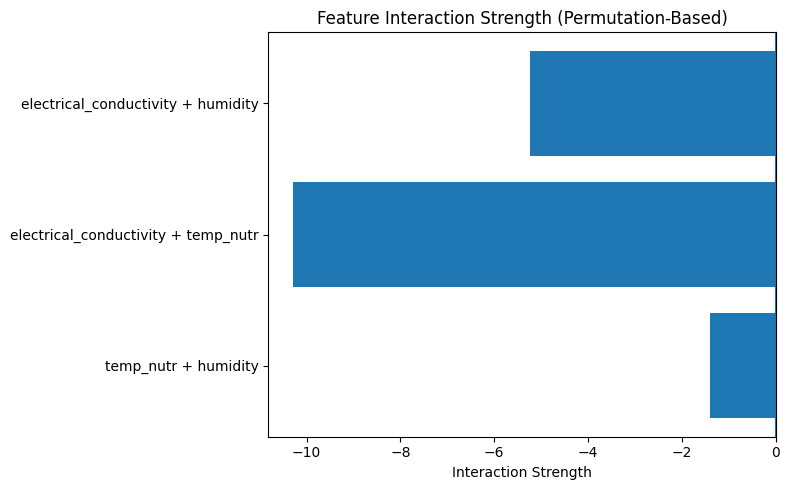

In [16]:
# ==============================
# Compute interaction strengths
# ==============================

# Store deltas in a dictionary
delta_dict = {}
for name, avg_rmse, _ in perm_results:
    delta_dict[name] = avg_rmse - base_rmse

print("\nInteraction Strengths:\n")

# Pairwise interactions only
for name in delta_dict:
    if " + " in name and name.count("+") == 1:
        f1, f2 = name.split(" + ")

        interaction = (
            delta_dict[name]
            - delta_dict[f1]
            - delta_dict[f2]
        )

        print(f"{name:50s} Interaction = {interaction:+.4f}")

pairs = []
interactions = []

for name in delta_dict:
    if " + " in name and name.count("+") == 1:
        f1, f2 = name.split(" + ")

        interaction = (
            delta_dict[name]
            - delta_dict[f1]
            - delta_dict[f2]
        )

        pairs.append(name)
        interactions.append(interaction)

plt.figure(figsize=(8, 5))
plt.barh(pairs[::-1], interactions[::-1])
plt.axvline(0)  # zero reference line

plt.xlabel("Interaction Strength")
plt.title("Feature Interaction Strength (Permutation-Based)")
plt.tight_layout()
plt.show()

## Partial Dependence Plots

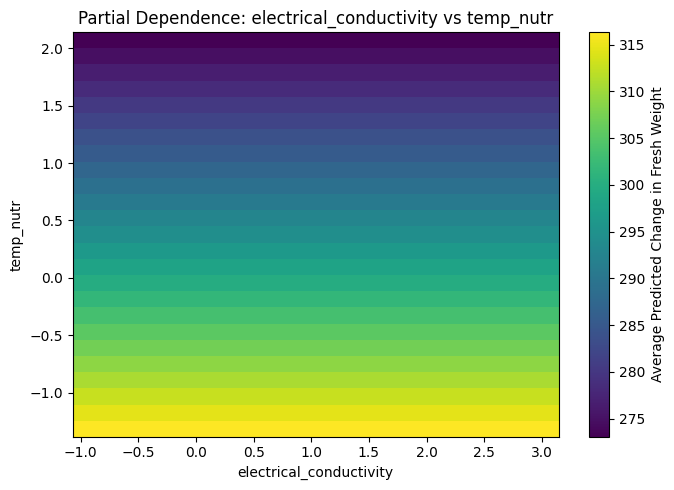

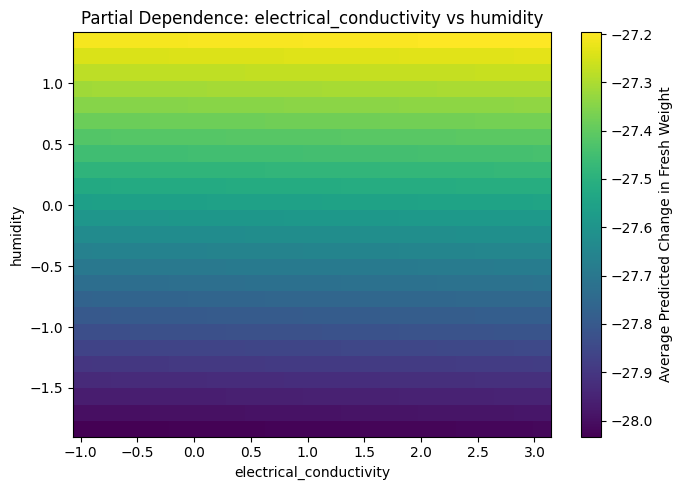

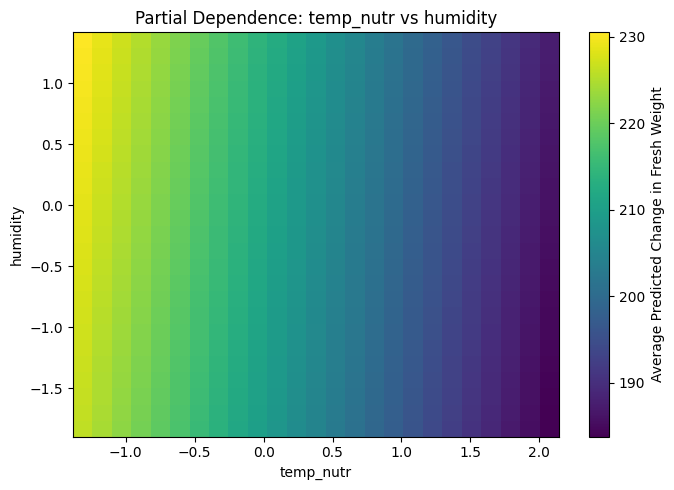

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# make sure model is in eval mode
model2.eval()

# feature pairs to examine
feature_pairs = [
    ("electrical_conductivity", "temp_nutr"),
    ("electrical_conductivity", "humidity"),
    ("temp_nutr", "humidity"),
]

# map feature names to column indices
name_to_idx = {name: i for i, name in enumerate(feature_names)}

# use the ORIGINAL unscaled training data to define realistic value ranges
# and use the SCALED test tensor as the base data that gets modified
X_reference = X_test_tensor.clone()

grid_size = 25

for feat1, feat2 in feature_pairs:
    idx1 = name_to_idx[feat1]
    idx2 = name_to_idx[feat2]
    
    # grid in original feature units
    vals1_raw = np.linspace(X_train[:, idx1].min(), X_train[:, idx1].max(), grid_size)
    vals2_raw = np.linspace(X_train[:, idx2].min(), X_train[:, idx2].max(), grid_size)
    
    pdp = np.zeros((grid_size, grid_size))
    
    for i, v1_raw in enumerate(vals1_raw):
        for j, v2_raw in enumerate(vals2_raw):
            X_temp = X_reference.clone()
            
            # standardize using the fitted scaler from final model training
            v1_scaled = (v1_raw - scaler.mean_[idx1]) / scaler.scale_[idx1]
            v2_scaled = (v2_raw - scaler.mean_[idx2]) / scaler.scale_[idx2]
            
            X_temp[:, idx1] = v1_scaled
            X_temp[:, idx2] = v2_scaled
            
            with torch.no_grad():
                preds = model2(X_temp).cpu().numpy()
            
            pdp[j, i] = preds.mean()
    
    plt.figure(figsize=(7, 5))
    plt.imshow(
        pdp,
        origin="lower",
        aspect="auto",
        extent=[vals1_raw.min(), vals1_raw.max(), vals2_raw.min(), vals2_raw.max()]
    )
    plt.colorbar(label="Average Predicted Change in Fresh Weight")
    plt.xlabel(feat1)
    plt.ylabel(feat2)
    plt.title(f"Partial Dependence: {feat1} vs {feat2}")
    plt.tight_layout()
    plt.savefig(f"../Figures/tcombined_m2_pdp_{feat1}_{feat2}.png", bbox_inches="tight")
    plt.show()

## ice plots

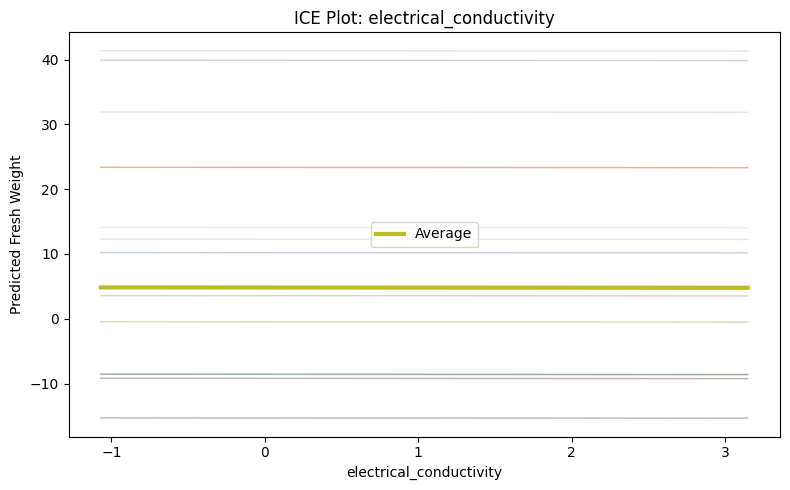

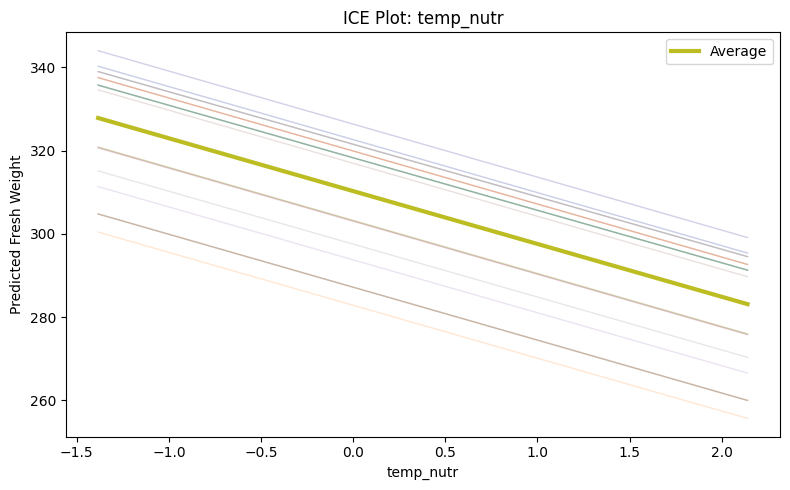

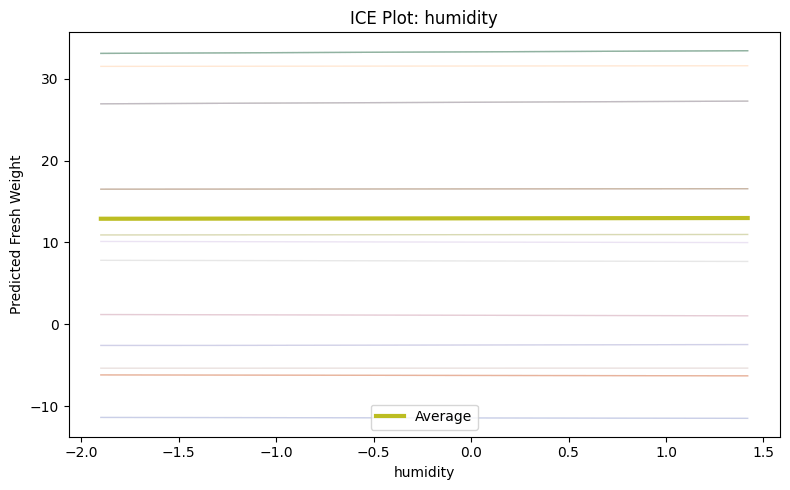

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

model2.eval()

name_to_idx = {name: i for i, name in enumerate(feature_names)}

features_to_plot = [
    "electrical_conductivity",
    "temp_nutr",
    "humidity"
]

# use scaled test set as base
X_reference = X_test_tensor.clone()

# use original feature units for plotting
grid_size = 25
n_lines = 80  # subsample ICE lines so plot stays readable

# optional reproducibility
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_reference.shape[0], size=min(n_lines, X_reference.shape[0]), replace=False)

for feat in features_to_plot:
    idx = name_to_idx[feat]

    vals_raw = np.linspace(X_train[:, idx].min(), X_train[:, idx].max(), grid_size)

    ice_curves = []

    for row_idx in sample_idx:
        preds_curve = []
        x0 = X_reference.clone()

        for v_raw in vals_raw:
            x_temp = x0.clone()

            # convert raw value to scaled value expected by model
            v_scaled = (v_raw - scaler.mean_[idx]) / scaler.scale_[idx]
            x_temp[row_idx, idx] = v_scaled

            with torch.no_grad():
                pred = model2(x_temp[row_idx:row_idx+1]).cpu().numpy().item()

            preds_curve.append(pred)

        ice_curves.append(preds_curve)

    ice_curves = np.array(ice_curves)
    pdp_curve = ice_curves.mean(axis=0)

    plt.figure(figsize=(8, 5))

    # ICE lines
    for curve in ice_curves:
        plt.plot(vals_raw, curve, alpha=0.18, linewidth=1)

    # Average line (PDP-like summary)
    plt.plot(vals_raw, pdp_curve, linewidth=3, label="Average")

    plt.xlabel(feat)
    plt.ylabel("Predicted Fresh Weight")
    plt.title(f"ICE Plot: {feat}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../Figures/ice_{feat}.png", bbox_inches="tight")
    plt.show()

/Users/gerardogutierrez/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/b2/dv4s0x994dz37s4d7fv56q8r0000gn/T/ipykernel_48098/1574194697.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/Users/gerardogutierrez/Library/Python/3.9/lib/python/site-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


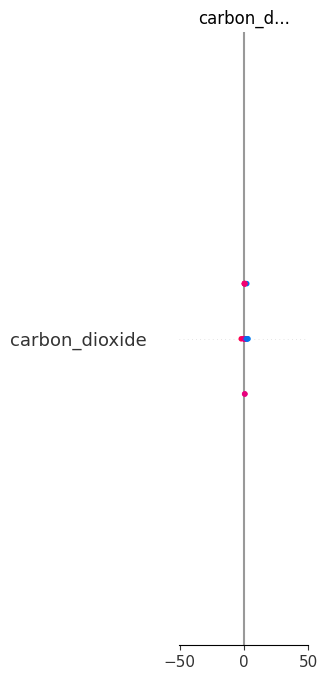

In [19]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

model2.eval()

# background data: small representative sample from training set
background_size = 100
explain_size = 200

rng = np.random.default_rng(42)
bg_idx = rng.choice(X_train_tensor.shape[0], size=min(background_size, X_train_tensor.shape[0]), replace=False)
ex_idx = rng.choice(X_test_tensor.shape[0], size=min(explain_size, X_test_tensor.shape[0]), replace=False)

background = X_train_tensor[bg_idx]
X_explain = X_test_tensor[ex_idx]

explainer = shap.GradientExplainer(model2, background)
shap_values = explainer.shap_values(X_explain)

# Depending on SHAP/model output shape, shap_values may already be [n_samples, n_features]
# or wrapped in a list. Normalize that:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

X_explain_np = X_explain.cpu().numpy()

# summary plot
shap.summary_plot(
    shap_values,
    X_explain_np,
    feature_names=feature_names,
    show=True
)

In [20]:
# electrical_conductivity
shap.dependence_plot(
    "electrical_conductivity",
    shap_values,
    X_explain.cpu().numpy(),
    feature_names=feature_names
)

# temp_nutr
shap.dependence_plot(
    "temp_nutr",
    shap_values,
    X_explain.cpu().numpy(),
    feature_names=feature_names
)

# humidity
shap.dependence_plot(
    "humidity",
    shap_values,
    X_explain.cpu().numpy(),
    feature_names=feature_names
)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 1 and the array at index 1 has size 2

# convert back to original scale

We want to raise average 4 day humidity by one standard deviaion in the next experiment. 



In [ ]:
df_5 = load_combined_data()

In [ ]:
df_5

,day,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
0,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,4.0
1,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.2
2,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,6.7
3,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,7.3
4,4.0,487.000000,22.425714,62.214082,99060.374490,1361.010204,23.987102,8.3
...,...,...,...,...,...,...,...,...
135,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,77.0
136,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,78.0
137,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,79.0
138,28.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286,80.0


In [22]:
df

,++10% effect (g),--10% effect (g),+-10% effect (g),-+10% effect (g),++20% effect (g),--20% effect (g),+-20% effect (g),-+20% effect (g)
feature_pair,,,,,,,,
humidity + electrical_conductivity,1.8616,-1.9472,-1.1084,1.0893,3.7510,-3.8752,-2.2249,2.2979
electrical_conductivity + temp_nutr,1.6652,-1.5654,1.3225,-1.4691,3.3605,-3.1221,2.6771,-2.9571
humidity + temp_nutr,0.5118,-0.5299,0.2807,-0.2683,0.9865,-1.0124,0.5926,-0.4938


In [ ]:
df_5

# increase temperature by 10% find average

In [17]:
df_5.describe()

,day,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,16.000000,509.517989,21.999440,66.818731,50008.718542,1580.194331,23.923137,27.355714
std,8.028725,124.588382,0.521860,7.627450,49395.834819,205.272353,1.575199,23.837689
min,4.000000,308.407597,21.244828,52.372857,621.142045,1361.010204,21.611981,-5.000000
25%,8.000000,487.000000,21.454400,62.214082,796.692551,1453.158710,22.273844,7.925000
50%,16.000000,507.612245,22.026053,68.792179,50047.810650,1494.233231,23.772489,15.600000
75%,24.000000,546.282779,22.425714,72.385926,99235.894082,1668.877551,25.308837,48.250000
max,28.000000,836.209532,22.804490,77.851267,99373.720000,2112.959184,26.928286,83.000000


In [21]:
# standard deviation per feature per 4 day period 
df_5.groupby('day').std().round(2)

,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
day,,,,,,,
4.0,72.47,0.51,5.22,50403.83,54.19,0.22,3.60
8.0,105.49,0.55,4.62,50522.16,36.50,0.26,2.73
12.0,170.58,0.14,4.06,50489.63,11.84,0.71,4.54
16.0,70.71,0.24,3.07,50312.13,125.04,1.58,3.91
20.0,10.74,0.72,9.23,50479.68,110.66,0.77,6.42
24.0,70.50,0.39,4.22,50632.74,333.83,1.90,11.04
28.0,17.83,0.42,3.07,50643.03,254.65,2.73,8.89


In [20]:
df_5.groupby('day').mean().round(2)

,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr,fw_change_g
day,,,,,,,
4.0,416.37,21.93,67.30,49932.80,1413.83,23.77,10.65
8.0,411.23,21.99,69.75,50039.60,1486.24,25.06,5.06
12.0,669.95,21.91,66.29,50024.69,1540.08,23.85,6.12
16.0,565.74,22.55,56.72,50073.44,1577.51,23.79,15.40
20.0,542.83,22.10,61.37,49985.60,1561.02,22.60,34.00
24.0,431.61,21.62,71.45,50023.03,1787.58,24.12,52.90
28.0,528.91,21.90,74.86,49981.86,1695.09,24.27,67.35


Plans for next experiment:

1. Increase humidity by one standard deviation for each 4 day period.
    - First 4 days: 67.3 + **5.22** = 72.52
    - Days 5-8: 69.75 + **4.62** = 74.37
    - Days 9-12: 66.29 + **4.06** = 70.35
    - Days 13-16: 56.72+ **3.07** = 59.79
    - Days 17-20: 61.37 + **9.23** = 70.60
    - Days 21-24: 71.45 + **4.22** = 75.67
    - Days 25-28: 74.86 + **3.07** = 77.93


Notes: 
* Day 16-20 had much higher deviation and was higher on average. 
* Need to account for day and night variability
*

# Neural Network 3
Combined Trials (1 and 2) - Target: `total_fresh_weight_g`, Features include `day`

In [2]:
# load_data_both: combines Trial 1 and Trial 2 sensor data, keeping total_fresh_weight_g
# (instead of fw_change_g) as the target, and keeping day as a feature.

def load_data_both():
    df_1 = pd.read_csv(TRIAL_1_DATA_PATH)
    # drop plant identifier and trial-1-only columns not present in trial 2
    df_1 = df_1.drop(columns=['plant-id', 'baseline_g', 'volume_flow_rate', 'volume'])

    df_2 = pd.read_csv(TRIAL_2_DATA_PATH)
    # drop plant identifier and the precomputed change column (not our target here)
    df_2 = df_2.drop(columns=['plant_id', 'fw_change_g'])

    combined_df = pd.concat([df_1, df_2], ignore_index=True)
    combined_df.sort_values(by=['day', 'total_fresh_weight_g'], inplace=True)
    combined_df.reset_index(drop=True, inplace=True)
    return combined_df

df_both = load_data_both()
df_both

,day,total_fresh_weight_g,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,temp_nutr
0,0.0,29.1,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208
1,0.0,29.1,0.323495,20.285433,83.790346,795.159839,1437.553398,22.909825
2,0.0,29.3,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208
3,0.0,29.3,0.323495,20.285433,83.790346,795.159839,1437.553398,22.909825
4,0.0,29.6,461.250000,22.528333,62.394167,98838.439167,1300.625000,23.835208
...,...,...,...,...,...,...,...,...
155,28.0,244.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286
156,28.0,246.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286
157,28.0,246.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286
158,28.0,248.0,511.530612,22.304286,71.859592,99342.587347,1943.295918,26.928286


## Leave-One-Out Cross-Validation

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

target_col = 'total_fresh_weight_g'

X_both = df_both.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y_both = df_both[target_col].to_numpy(dtype=np.float32)
feature_names_both = df_both.drop(columns=[target_col]).columns.tolist()

#### Neural Network Model
class TotalFWNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# hyperparameters
hidden_size = 32
output_size = 1
learning_rate = 0.01
num_epochs = 1500

criterion = nn.MSELoss()

torch.manual_seed(42)

loo = LeaveOneOut()
n_samples = X_both.shape[0]
oof_preds = np.zeros(n_samples, dtype=np.float32)

for fold, (train_idx, test_idx) in enumerate(loo.split(X_both)):
    X_train_fold, X_test_fold = X_both[train_idx], X_both[test_idx]
    y_train_fold = y_both[train_idx]

    # standardize features within each fold using only training data
    x_scaler = StandardScaler()
    X_train_fold = x_scaler.fit_transform(X_train_fold).astype(np.float32)
    X_test_fold = x_scaler.transform(X_test_fold).astype(np.float32)

    # standardize target within each fold so the loss surface is well-conditioned
    y_scaler = StandardScaler()
    y_train_fold_scaled = y_scaler.fit_transform(y_train_fold.reshape(-1, 1)).astype(np.float32)

    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_fold, dtype=torch.float32)

    model = TotalFWNN(input_size=X_both.shape[1], hidden_size=hidden_size, output_size=output_size)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    for epoch in range(num_epochs):
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test_tensor).item()
    # inverse-transform prediction back to original fresh-weight units
    pred = y_scaler.inverse_transform([[pred_scaled]])[0, 0]
    oof_preds[test_idx[0]] = pred

    if (fold + 1) % 20 == 0 or (fold + 1) == n_samples:
        print(f"Completed LOO fold {fold + 1}/{n_samples}")

r2_loo = r2_score(y_both, oof_preds)
rmse_loo = np.sqrt(mean_squared_error(y_both, oof_preds))

print(f"\nLeave-One-Out R-squared: {r2_loo:.4f}")
print(f"Leave-One-Out RMSE (g): {rmse_loo:.4f}")
print(f"n = {n_samples}")

Completed LOO fold 20/160
Completed LOO fold 40/160
Completed LOO fold 60/160
Completed LOO fold 80/160
Completed LOO fold 100/160
Completed LOO fold 120/160
Completed LOO fold 140/160
Completed LOO fold 160/160

Leave-One-Out R-squared: 0.9864
Leave-One-Out RMSE (g): 7.4093
n = 160


## Reproduce Reference Graphs
Left: cross-validated (leave-one-out) predicted vs. observed fresh weight. Right: relative feature importance for predicting biomass.

In [5]:
# Train a final model on the full dataset (standardized) for permutation feature importance

x_scaler_full = StandardScaler()
X_full_scaled = x_scaler_full.fit_transform(X_both).astype(np.float32)

y_scaler_full = StandardScaler()
y_full_scaled = y_scaler_full.fit_transform(y_both.reshape(-1, 1)).astype(np.float32)

X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)
y_full_tensor = torch.tensor(y_full_scaled, dtype=torch.float32)

torch.manual_seed(42)
final_model = TotalFWNN(input_size=X_both.shape[1], hidden_size=hidden_size, output_size=output_size)
optimizer = optim.Adam(final_model.parameters(), lr=learning_rate)

final_model.train()
for epoch in range(num_epochs):
    outputs = final_model(X_full_tensor)
    loss = criterion(outputs, y_full_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

final_model.eval()
with torch.no_grad():
    base_preds_scaled = final_model(X_full_tensor).cpu().numpy().reshape(-1)
base_preds = y_scaler_full.inverse_transform(base_preds_scaled.reshape(-1, 1)).reshape(-1)
base_rmse_full = np.sqrt(mean_squared_error(y_both, base_preds))

# permutation importance (20 repeats per feature)
repeats = 20
torch.manual_seed(42)
N_full = X_full_tensor.shape[0]

perm_deltas = []
for j, name in enumerate(feature_names_both):
    rmses = []
    for r in range(repeats):
        X_perm = X_full_tensor.clone()
        idx = torch.randperm(N_full)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds_scaled = final_model(X_perm).cpu().numpy().reshape(-1)
        preds = y_scaler_full.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(-1)
        rmses.append(np.sqrt(mean_squared_error(y_both, preds)))

    perm_deltas.append(np.mean(rmses) - base_rmse_full)

# convert to non-negative relative importance percentages (summing to 100)
perm_deltas = np.clip(np.array(perm_deltas), a_min=0, a_max=None)
if perm_deltas.sum() > 0:
    relative_importance_pct = 100 * perm_deltas / perm_deltas.sum()
else:
    relative_importance_pct = np.zeros_like(perm_deltas)

importance_df = pd.DataFrame({
    'feature': feature_names_both,
    'relative_importance_pct': relative_importance_pct
}).sort_values('relative_importance_pct', ascending=False).reset_index(drop=True)

print(importance_df)

                   feature  relative_importance_pct
0                      day                33.231173
1                 humidity                26.554802
2                 temp_env                14.927208
3  electrical_conductivity                 8.202452
4                 pressure                 6.200011
5           carbon_dioxide                 5.673565
6                temp_nutr                 5.210788


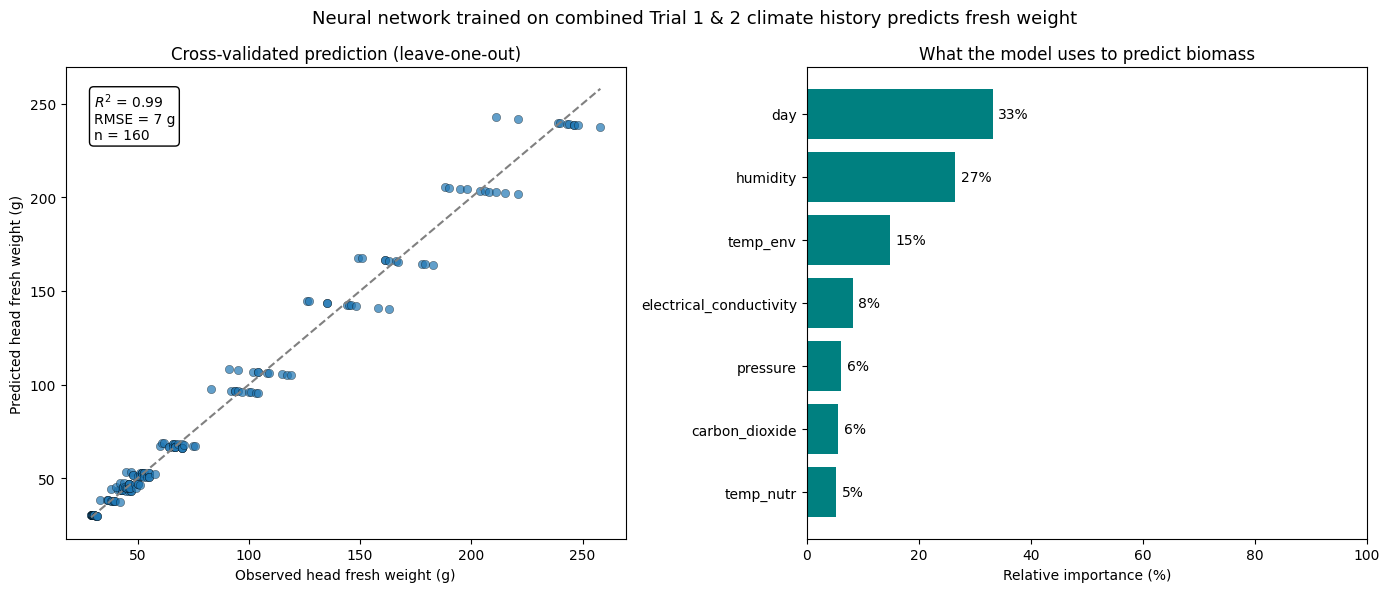

In [6]:
import matplotlib.pyplot as plt
import os

os.makedirs('../Figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left panel: cross-validated (leave-one-out) predicted vs observed ----
ax = axes[0]
ax.scatter(y_both, oof_preds, alpha=0.7, edgecolor='black', linewidth=0.3)

min_val = min(y_both.min(), oof_preds.min())
max_val = max(y_both.max(), oof_preds.max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray')

textstr = f"$R^2$ = {r2_loo:.2f}\nRMSE = {rmse_loo:.0f} g\nn = {n_samples}"
ax.text(
    0.05, 0.95, textstr, transform=ax.transAxes,
    va='top', ha='left',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='black')
)

ax.set_xlabel("Observed head fresh weight (g)")
ax.set_ylabel("Predicted head fresh weight (g)")
ax.set_title("Cross-validated prediction (leave-one-out)")

# ---- Right panel: relative feature importance ----
ax2 = axes[1]
plot_importance_df = importance_df.iloc[::-1]  # smallest to largest for horizontal bar plot
bars = ax2.barh(plot_importance_df['feature'], plot_importance_df['relative_importance_pct'], color='teal')

for bar, value in zip(bars, plot_importance_df['relative_importance_pct']):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va='center')

ax2.set_xlim(0, 100)
ax2.set_xlabel("Relative importance (%)")
ax2.set_title("What the model uses to predict biomass")

plt.suptitle("Neural network trained on combined Trial 1 & 2 climate history predicts fresh weight", fontsize=13)
plt.tight_layout()
plt.savefig('../Figures/nn3_loocv_prediction_and_feature_importance.png', bbox_inches='tight')
plt.show()